# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

# Dataset Description

I chose to use a dataset for Meteorite Landings collected by NASA. It contains information on more than 45,000 meteorites that have fallen or been found on Earth. The dataset was obtained from NASA's Open Data Portal.

### Key Features:
    - name: Name of meteorite
    - id: Unique identifier
    - nametype: Whether the entry is valid or not
    - recclass: Classification type of meteorite
    - mass(g): Mass of the meteorite in grams
    - fall: Whether the meteorite was observed falling ("Fell") or later 
    discovered ("Found")
    - year: Year of the fall or discovery
    - reclat / reclong: Latitude and longitude of the meteorite landing site
    - Geolocation: Coordinate pair (lat, long)

I will analyze the spatial patterns (where they landed), temporal treands (how landings recorded across time), and relationships between variables (such as mass vs. year).

In [2]:
import plotly.express as px
import pandas as pd

# Load Dataset
df = pd.read_csv('Meteorite_Landings.csv')

df = df.dropna(subset=['year','reclat','reclong'])

df['year'] = df['year'].astype(int)

print(df.head())

       name   id nametype     recclass  mass (g)  fall  year    reclat  \
0    Aachen    1    Valid           L5      21.0  Fell  1880  50.77500   
1    Aarhus    2    Valid           H6     720.0  Fell  1951  56.18333   
2      Abee    6    Valid          EH4  107000.0  Fell  1952  54.21667   
3  Acapulco   10    Valid  Acapulcoite    1914.0  Fell  1976  16.88333   
4   Achiras  370    Valid           L6     780.0  Fell  1902 -33.16667   

     reclong           GeoLocation  
0    6.08333     (50.775, 6.08333)  
1   10.23333  (56.18333, 10.23333)  
2 -113.00000    (54.21667, -113.0)  
3  -99.90000     (16.88333, -99.9)  
4  -64.95000   (-33.16667, -64.95)  


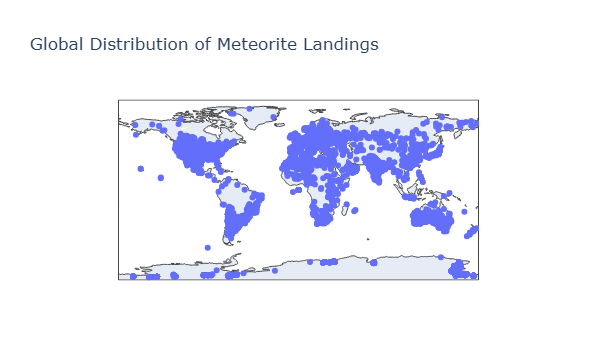

In [11]:
# Vis 1: World Map of Meteorite Landings

fig = px.scatter_geo(df,
                     lat='reclat',
                     lon='reclong',
                     hover_name='name',
                     title='Global Distribution of Meteorite Landings')
fig.show()

This interactive map shows the geographical locations across the globe of meteorite landing sites. The landings are clustered in specific regions likely due to discovery and preservation factors rather than uneven distribution of impacts.


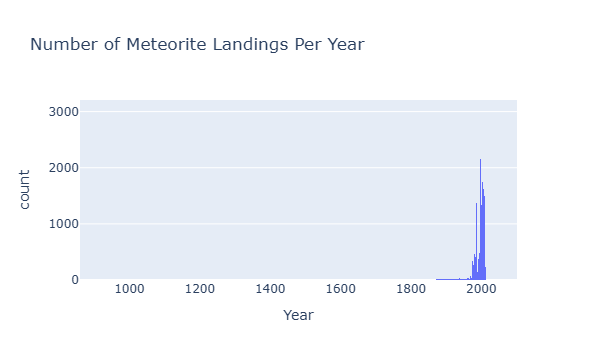

In [13]:
# Vis 2 Number of Meteorite Landings Over Time

fig = px.histogram(df,
                   x='year',
                   title='Number of Meteorite Landings Per Year',
                   labels={'year': 'Year', 'count': 'Number of Landings'})
fig.show()

The histogram illustrates the number of recorded meteorite landings per year. The chart shows a dramatic increase in the number of discoveries in recent decades. This is likely not due to more meteorites hitting the Earth, but rather to advancements in detection, technology, awareness, and more organized search efforts.


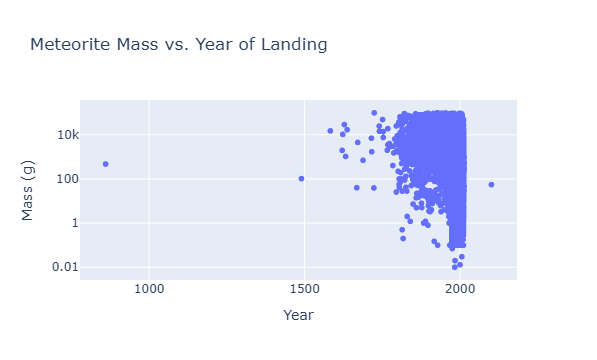

In [14]:
# Vis 3 Meteorite Mass vs. Year of Landing

df_filtered = df[df['mass (g)'] < 100000].copy()

fig = px.scatter(df_filtered,
                 x='year',
                 y='mass (g)',
                 log_y=True,  # Using a log scale for the y-axis
                 title='Meteorite Mass vs. Year of Landing',
                 labels={'year': 'Year', 'mass (g)': 'Mass (g)'},
                 hover_data=['name'])
fig.show()

This scatter plot shows the relationship between the mass of the meteorites and they year they were recorded. There does not appear to be a clear trend indicating that larger or smaller meteorites have been found more frequentlyover time. The distribution of masses appears to be relatively consistent throughout the recorded history of meteorite landings.


# Conclusion

Through this lab I explored the spatial and temporal relationships in the Meteorite Landings dataset.

Spatial: Meteorite landings are spread across the globe but cluster in regions with more scientific exploration and documentation.
Temporal: The number of documented meteorite landings increases dramatically in recent decades, which is reflective of advancements in detection and record-keeping rather than an actual increase. 
Mass vs. Year: The distribution of meteorite masses remains fairly constant across time, suggesting that discovery rates are not strongly influenced by meteorite size. 

This lab demonstrates how spatial and temporal visualizations can reveal patterns in global datasets, and how context (such as improvement in technology and research) is crucial for interpreting trends.